### [ 블러링 - 미디언블러/양방향필터 ] <hr>
- 이미지에 작은 흰색점(소금), 검은점(후추) 제거에 탁월한 블러 : 미디언 블러
    * 컨블루션 연산 수행 X
    * 커널 용도 : 범위 지정 => 이미지의 픽셀들
    * 픽셀들 오름차순 정렬 => 중앙값 추출 => 픽셀의 가운데 픽셀값 교체
- 이미지의 노이즈/잡티 제거 후 추가로 경계선 선명하게 처리 : 양방향 필터

In [1]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, sys
sys.path.append(r'C:\Users\Win11Pro\Desktop\KDT-14\[7]_CVISION')
from cv_utils import *

In [3]:
IMG_FILE = '../Data/images/salt_pepper_noise.jpg'

In [4]:
# 이미지 데이터 로딩 및 기본 정보 확인
img = cv2.imread(IMG_FILE)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f'[기본정보] shape : {img.shape}, ndim : {img.ndim}, dtype : {img.dtype}')

[기본정보] shape : (268, 218, 3), ndim : 3, dtype : uint8


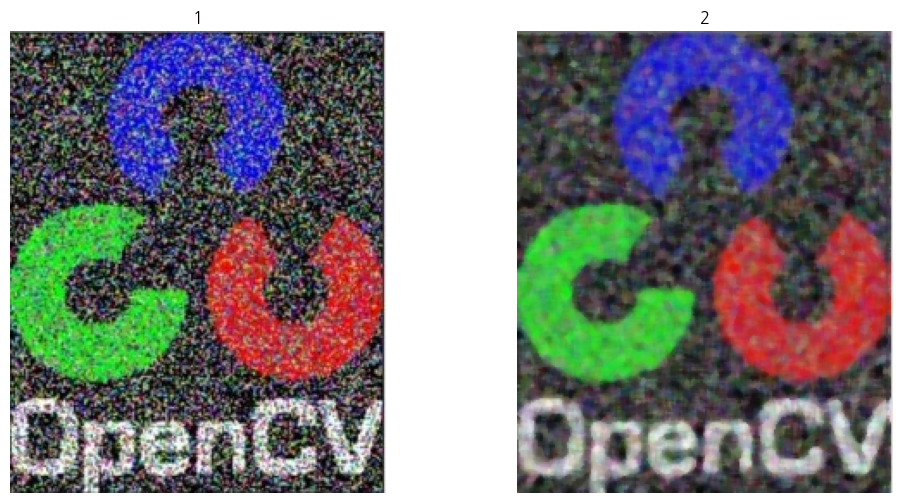

In [6]:
blur = cv2.medianBlur(img, 5)

printPolts(1,2, ['1','2'], [img,blur])

### [ 양방향필터 ] <hr>
- 선택된 픽셀에서 중앙픽셀을 기준으로 거리, 색상차에 따른 가중치 부여
    * [거리] 중심픽셀 -> 가까운 픽셀 : 가중치 높음 | 멀리 있는 픽셀 : 가중치 낮음
    * [색상] 중심픽셀 -> 색상값 비슷한 픽셀 : 가중치 높음
- 고정된 값의 커널 없음
    * 매번 중심 픽셀이 변경되기 때문에 매번 계산 필요 => 느림
- 픽셀의 색상차를 고려하기 때문에 경계 부분이 유지 가능

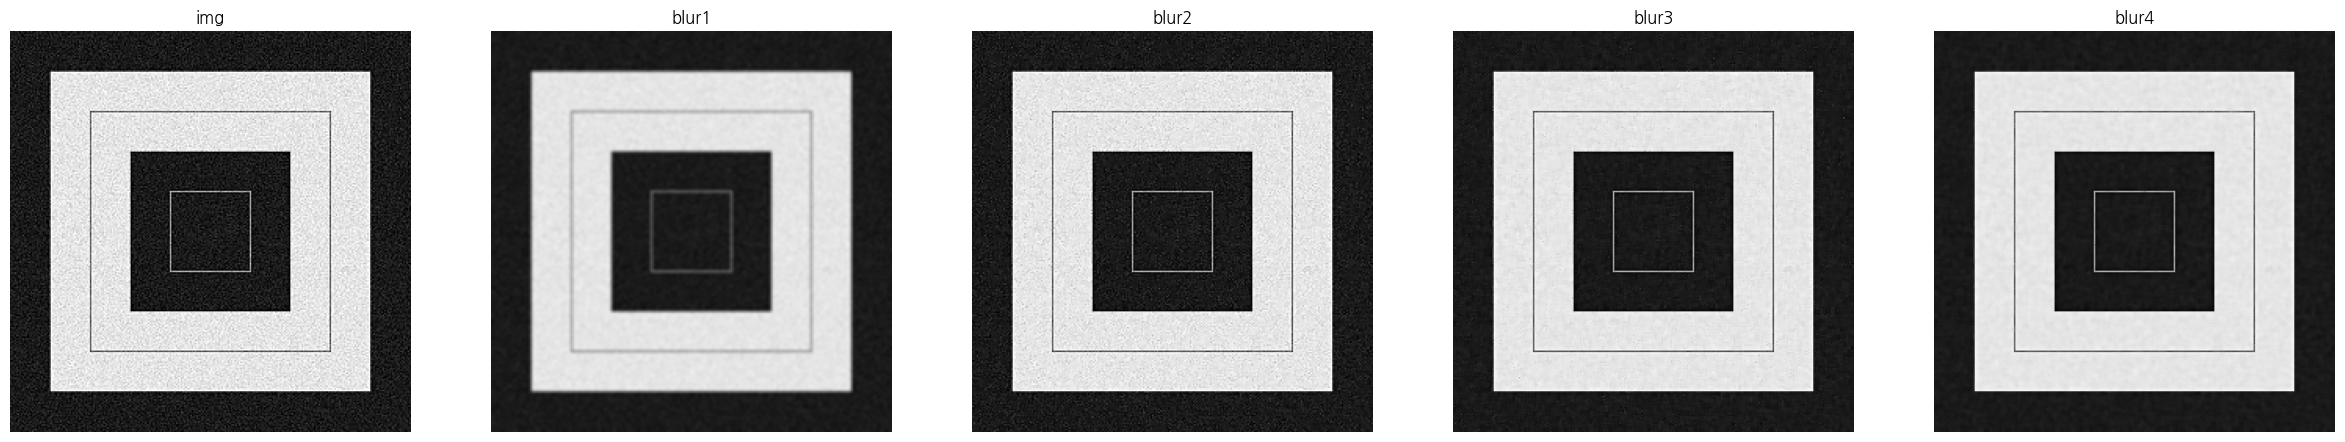

In [ ]:
img = cv2.imread('../Data/images/gaussian_noise.jpg')
blur1 = cv2.GaussianBlur(img, (5,5), 0)
blur2 = cv2.bilateralFilter(img, 5, 30, 30)
blur3 = cv2.bilateralFilter(img, 5, 70, 70)     
blur4 = cv2.bilateralFilter(img, 5, 150, 150)
printPolts(1,5, ['img', 'blur1', 'blur2', 'blur3', 'blur4'], [img, blur1, blur2, blur3, blur4])